In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("cleaned_visa_data.csv")
print(df.head())

  Applicant_Country Visa_Type Processing_Office Application_Date  \
0               USA      Work            London       2022-03-19   
1           Germany      Work         Hyderabad       2022-09-03   
2               USA   Tourist            London       2022-03-25   
3            Canada   Tourist           Toronto       2022-12-21   
4             India   Tourist         New Delhi       2022-04-07   

  Decision_Date  Applicant_Age  Experience_Years  Processing_Time_Days  
0    2022-06-26             62              22.0                    99  
1    2022-09-26             60              24.0                    23  
2    2022-06-30             63               4.0                    97  
3    2022-12-26             37              12.0                     5  
4    2022-06-12             26              13.0                    66  


In [3]:
#feature engineering
df["Application_Date"] = pd.to_datetime(df["Application_Date"])

df["Application_Month"] = df["Application_Date"].dt.month

In [4]:
df = pd.get_dummies(df, columns=[
"Applicant_Country",
"Visa_Type",
"Processing_Office"
], drop_first=True)

In [5]:
#features and target
X = df.drop([
"Processing_Time_Days",
"Application_Date",
"Decision_Date"
], axis=1)

y = df["Processing_Time_Days"]

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [7]:
#training models
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
rf = RandomForestRegressor(
n_estimators=100,
random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
gb = GradientBoostingRegressor(
n_estimators=100,
learning_rate=0.1)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [10]:
#evaluate model
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2


In [11]:
#compare models
lr_metrics = evaluate_model(y_test, lr_pred)
rf_metrics = evaluate_model(y_test, rf_pred)
gb_metrics = evaluate_model(y_test, gb_pred)

print("Linear Regression:", lr_metrics)
print("Random Forest:", rf_metrics)
print("Gradient Boosting:", gb_metrics)

Linear Regression: (83.13006268001848, np.float64(96.44593209925203), -5.511272472945473)
Random Forest: (43.42285714285715, np.float64(47.71209699856002), -0.5935109400000003)
Gradient Boosting: (53.6330377480537, np.float64(58.65635596561263), -1.4083976666152624)


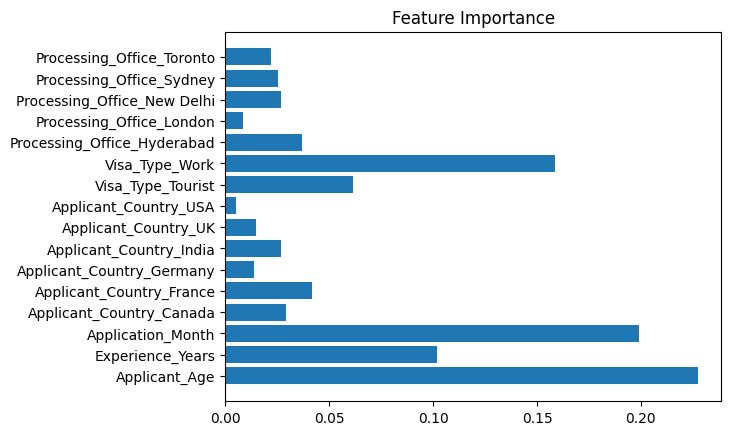

In [12]:
#feature importance
importance = rf.feature_importances_
features = X.columns
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [13]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,None]
}
grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3
)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [16]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Save model
joblib.dump(rf_model, "rf_model.pkl")

# Save feature column order (VERY IMPORTANT)
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model saved successfully")

Model saved successfully
